In [1]:
# Question 8: Clustering Text Data
# Description: Apply K-Means clustering to a set of text documents (e.g., news articles) after using TF-IDF for feature extraction.

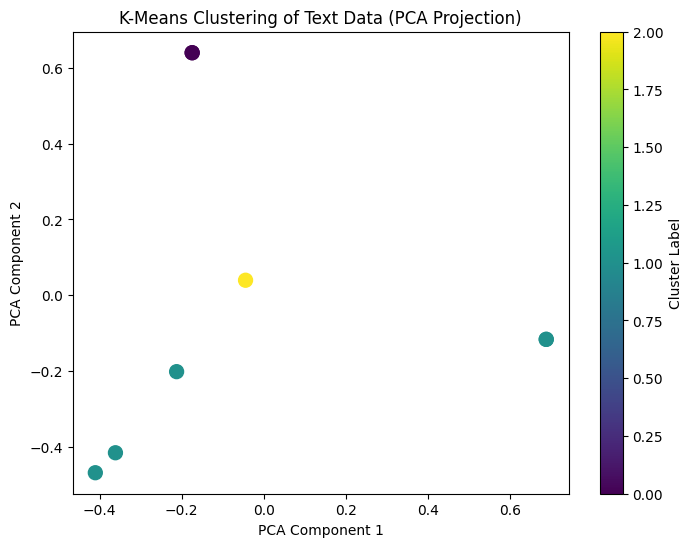

Cluster 0 top terms: technology, ai, innovation, advances, driving
Cluster 1 top terms: sports, football, basketball, stock, market
Cluster 2 top terms: fast, economy, stocks, growing, young


In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd
documents = [
    "The economy is growing fast and stocks are up.",
    "Sports events are gaining popularity among young people.",
    "New technology trends include AI and machine learning.",
    "The stock market is volatile amid economic uncertainty.",
    "Football and basketball are popular sports worldwide.",
    "AI advances are driving innovation in technology.",
    "Economic policies impact stock prices and market stability.",
    "Fans love watching basketball and football games live."
]
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(documents)
num_clusters = 3
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
kmeans.fit(X)

labels = kmeans.labels_
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=100)

plt.title('K-Means Clustering of Text Data (PCA Projection)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(scatter, label='Cluster Label')
plt.show()
def print_top_terms_per_cluster(kmeans, vectorizer, n_terms=5):
    terms = vectorizer.get_feature_names_out()
    order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
    
    for i in range(num_clusters):
        top_terms = [terms[ind] for ind in order_centroids[i, :n_terms]]
        print(f"Cluster {i} top terms: {', '.join(top_terms)}")

print_top_terms_per_cluster(kmeans, vectorizer)
